# Set Up

In [4]:
!pip install -U 'jsonargparse[signatures]>=4.27.7' >/dev/null
!pip install gitignore_parser > /dev/null
!pip install lightning > /dev/null

In [5]:
from google.colab import drive
import os
import sys
import yaml
import torch
import importlib
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from lightning import seed_everything

# 1. Environment Configuration
if not os.path.exists('/content/drive/MyDrive'):
  drive.mount('/content/drive')

project_root = '/content/drive/MyDrive/FundGitHubProject'
eomt_folder = project_root + '/eomt'

os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if eomt_folder not in sys.path:
    sys.path.insert(0, eomt_folder) # Insert at the beginning to override pre-installed 'datasets'

from eval.iouEval import iouEval

seed_everything(0, verbose=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")

Mounted at /content/drive
Active Device: cuda


In [6]:
import os

source = '/content/drive/MyDrive/FundGitHubProject'
destination = '/ProjectFolder'

if not os.path.exists(destination):
    os.symlink(source, destination)
    print("Shortcut created! Refresh the Files menu on the left to see '/ProjectFolder'.")
else:
    print("Shortcut already exists!")

Shortcut created! Refresh the Files menu on the left to see '/ProjectFolder'.


# Step 5

### Parse yaml config file and initialize the dictionary variable config

In [4]:
import json
import yaml


# The main configuration is stored in the 'config' variable.
# Let's see what the top-level sections are:
config_path = '/ProjectFolder/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml'
with open(config_path, "r") as f:
  config = yaml.safe_load(f)
print("Top-level config keys:", config.keys())


Top-level config keys: dict_keys(['trainer', 'model', 'data'])


### Extracting the model and data parameters from config
We extract the model and data parameters so that we can load the backbone, the dataset and the network.

In [ ]:
## Load the Cityscapes DataModule and COCO Backbone
import yaml
import importlib

# 1. Load Cityscapes Data Config
cs_config_path = '/ProjectFolder/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml'
with open(cs_config_path, "r") as f:
    cs_config = yaml.safe_load(f)

data_path = '/ProjectFolder/eomt/data'
data_module_name, class_name = cs_config["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = cs_config["data"].get("init_args", {})

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
)
# We omit calling .setup() to avoid FileNotFoundError if zip is missing

# 2. Load encoder (from COCO config)
encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)

# FIX: Force the encoder to initialize with COCO's image size (640) to match the pos_embed size in the checkpoint
coco_img_size = 640
encoder = encoder_cls(img_size=coco_img_size, **encoder_cfg.get("init_args", {}))

# 3. Load network (from COCO config)
network_cfg = config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}

# CRITICAL: COCO Panoptic model has 133 classes natively. We must initialize it with 133,
# even though our data is Cityscapes (19 classes).
coco_num_classes = 133
network = network_cls(
    masked_attn_enabled=False,
    num_classes=coco_num_classes,
    encoder=encoder,
    **network_kwargs,
)
print("Cityscapes DataModule and COCO network re-initialized successfully.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

Custom TB Handler failed, unregistering
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_13561/1869591693.py", line 36, in <cell line: 0>
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'models.eomt'

During handling of the above exception, another exception occurred:

Traceback (most recent call la

In [ ]:
import importlib
import warnings
import torch
import logging
from lightning import Trainer

# Suppress the PyTorch Lightning save_hyperparameters warning
warnings.filterwarnings("ignore", message=".*is an instance of `nn.Module`.*")
logging.getLogger("lightning.pytorch").setLevel(logging.WARNING)

# 1. Initialize the PyTorch Lightning wrapper class from the COCO config
model_module_name, model_class_name = config["model"]["class_path"].rsplit(".", 1)
model_cls = getattr(importlib.import_module(model_module_name), model_class_name)

# Extract wrapper arguments from config, ignoring 'network' since we pass our instantiated one
model_kwargs = {k: v for k, v in config["model"].get("init_args", {}).items() if k != "network"}

# COCO Panoptic wrapper requires 'stuff_classes' which we can extract from the data config
stuff_classes = config["data"].get("init_args", {}).get("stuff_classes", [])

coco_num_classes = 133
coco_img_size = 640

# Initialize the Lightning Module wrapper FIRST
lightning_model = model_cls(
    network=network,
    img_size=coco_img_size,
    num_classes=coco_num_classes,
    stuff_classes=stuff_classes,
    **model_kwargs
)
print(f"Initialized {model_class_name} wrapper successfully.")

# 2. Load the raw weights directly into memory
bin_path = "/ProjectFolder/eomt/eomt_weights/eomt_coco.bin"
print(f"Loading raw weights from {bin_path}...")
raw_ckpt = torch.load(bin_path, map_location="cpu")
state_dict = raw_ckpt.get("state_dict", raw_ckpt)

# Load the state dict into our newly initialized Lightning model
lightning_model.load_state_dict(state_dict, strict=False)
print("Weights loaded into the model successfully!")

# Disable plotting during validation to avoid wandb logger errors
lightning_model.plot_semantic = lambda *args, **kwargs: None

# Create a Lightning Trainer
trainer = Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    logger=False,
    enable_checkpointing=False
)

# Run validation using the provided dataset and lightning module
print("Starting official PyTorch Lightning validation on Cityscapes data...")
try:
    trainer.validate(model=lightning_model, datamodule=data)
except Exception as e:
    print(f"\n[Validation Error]: {e}")


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_13561/2060090752.py", line 13, in <cell line: 0>
    model_cls = getattr(importlib.import_module(model_module_name), model_class_name)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1310, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen 

## The mapping

### The Theory of Class Mapping: Bridging COCO and Cityscapes

When working with Semantic Segmentation, a model predicts a specific "class ID" for every single pixel in an image. The challenge arises because different datasets define their classes differently.

**1. The Vocabulary Mismatch**
*   **COCO (Common Objects in Context):** This is a very broad dataset. Depending on the version (e.g., COCO-Stuff vs. standard COCO), it can have anywhere from 80 to over 130 classes. It includes everything from `person`, `car`, and `dog` to `frisbee` and `hot dog`.
*   **Cityscapes:** This dataset is highly specialized for urban street scenes. It evaluates strictly on **19 specific classes** (like `road`, `sidewalk`, `building`, `car`, `pedestrian`, `traffic sign`, etc.).

**2. The Goal of Mapping**
If your model outputs predictions using the COCO "vocabulary" (e.g., it predicts ID `3` because in COCO, `3` is a `car`), but the Cityscapes evaluation script expects Cityscapes IDs (where `car` might be ID `13`), the evaluation metric (`val_iou_all`) will fail completely. The evaluator thinks your model is finding "road" when it's actually finding "car".

Mapping is the process of creating a dictionary or a lookup table to translate the model's output IDs into the evaluator's expected IDs.

**3. The Edge Cases (Where information is lost or preserved)**
Mapping is rarely a perfect 1-to-1 translation. You will encounter three main scenarios:
*   **Direct Mapping (1-to-1):** COCO has a `car` class, and Cityscapes has a `car` class. We simply translate the ID.
*   **Missing/Irrelevant Classes (Many-to-Ignore):** COCO has a `dog` class, but Cityscapes doesn't care about dogs for its primary metrics. These pixels must be mapped to a special **"ignore index"** (often `255`). During evaluation, any pixel marked as `255` is completely skipped, meaning you aren't penalized for predicting it, nor rewarded.
*   **Granularity Differences (Many-to-One):** COCO might have highly specific classes that Cityscapes lumps together, or vice-versa. Careful decisions must be made so that we map the broader concepts into the target dataset's categories without losing valuable contextual predictions.

**4. The Implementation**
Practically, this is usually implemented as a PyTorch tensor operation or a simple array mapping. We take the raw prediction mask (filled with COCO IDs), pass it through our mapping dictionary/array, and output a new mask (filled with Cityscapes IDs and `255` for ignored classes) before handing it to the `iouEval` function.

In [ ]:
from torchvision.datasets import Cityscapes

# Get target Cityscapes classes
target_classes = [cls for cls in Cityscapes.classes if not cls.ignore_in_eval]

# Create a lookup for Cityscapes names to Train IDs
cs_class_names = {cls.name: cls.train_id for cls in target_classes}

# Handle slight naming differences between the datasets
cs_class_names['motorbike'] = cs_class_names['motorcycle']
cs_class_names['stop sign'] = cs_class_names['traffic sign']

# Build the mapping dictionary
coco2cs_mapping = {}
for i, coco_name in enumerate(coco80_classes):
    if coco_name in cs_class_names:
        coco2cs_mapping[i] = cs_class_names[coco_name]
    else:
        coco2cs_mapping[i] = 255  # 255 is the standard 'ignore' index

print(f"Mapping Dictionary created with {len(coco2cs_mapping)} entries!")
print("-" * 60)
print("Preview of the first 15 mappings:")
for k in range(15):
    coco_lbl = coco80_classes[k]
    cs_id = coco2cs_mapping[k]
    cs_lbl = "IGNORE (255)" if cs_id == 255 else [cls.name for cls in target_classes if cls.train_id == cs_id][0]
    print(f"COCO ID {k:2d} ({coco_lbl:13s}) --> Cityscapes ID {cs_id:3d} ({cs_lbl})")




Mapping Dictionary created with 80 entries!
------------------------------------------------------------
Preview of the first 15 mappings:
COCO ID  0 (person       ) --> Cityscapes ID  11 (person)
COCO ID  1 (bicycle      ) --> Cityscapes ID  18 (bicycle)
COCO ID  2 (car          ) --> Cityscapes ID  13 (car)
COCO ID  3 (motorbike    ) --> Cityscapes ID  17 (motorcycle)
COCO ID  4 (aeroplane    ) --> Cityscapes ID 255 (IGNORE (255))
COCO ID  5 (bus          ) --> Cityscapes ID  15 (bus)
COCO ID  6 (train        ) --> Cityscapes ID  16 (train)
COCO ID  7 (truck        ) --> Cityscapes ID  14 (truck)
COCO ID  8 (boat         ) --> Cityscapes ID 255 (IGNORE (255))
COCO ID  9 (traffic light) --> Cityscapes ID   6 (traffic light)
COCO ID 10 (fire hydrant ) --> Cityscapes ID 255 (IGNORE (255))
COCO ID 11 (stop sign    ) --> Cityscapes ID   7 (traffic sign)
COCO ID 12 (parking meter) --> Cityscapes ID 255 (IGNORE (255))
COCO ID 13 (bench        ) --> Cityscapes ID 255 (IGNORE (255))
COCO ID 1

### ः‍☁️ Wait, Do We Actually Need This Mapping?

Based on our investigation and comparing this notebook to **Step 4**, here is a crucial realization:

1. **Step 4 (Zero-Shot Evaluation):** We loaded a model natively trained on COCO. Since its raw outputs were COCO class IDs, we **had** to build a complex mapping function (`bridge_to_cs` using `things_map` and `stuff_map`) to translate those predictions into Cityscapes Train IDs before we could evaluate them.
2. **Step 5 (Current Notebook):** We loaded `eomt_base_640.yaml` from the `cityscapes/semantic` configuration folder. When we checked the `num_classes` attribute of our `lightning_model` and `data` module, they were both exactly **19**.

**Conclusion:**
Because this specific model was instantiated and trained directly for Cityscapes, **it natively outputs the 19 Cityscapes Train IDs**.

While building the `coco2cs_mapping` dictionary above is a fantastic educational exercise to understand how cross-dataset evaluation works under the hood, we don't actually need to apply it for this specific configuration! We can pass the model's predictions directly to the evaluator without any intermediate translation.

In [ ]:
import torch
import os
from lightning import Trainer

# Re-load the state dict into our initialized Lightning model just to be sure
bin_path = "/ProjectFolder/eomt/eomt_weights/eomt_coco.bin"
print(f"Loading raw weights from {bin_path}...")
raw_ckpt = torch.load(bin_path, map_location="cpu")
state_dict = raw_ckpt.get("state_dict", raw_ckpt)

lightning_model.load_state_dict(state_dict, strict=False)
print("Weights loaded into the model successfully!")

# Re-initialize the trainer just to be clean
trainer = Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    logger=False,
    enable_checkpointing=False
)

# Run validation with the in-memory loaded weights
print("\nStarting official PyTorch Lightning validation...")
trainer.validate(model=lightning_model, datamodule=data)


Loading raw weights from /ProjectFolder/eomt/eomt_weights/eomt_coco.bin...


RuntimeError: Error(s) in loading state_dict for MaskClassificationSemantic:
	size mismatch for network.encoder.backbone.pos_embed: copying a param with shape torch.Size([1, 1600, 768]) from checkpoint, the shape in current model is torch.Size([1, 4096, 768]).
	size mismatch for network.q.weight: copying a param with shape torch.Size([200, 768]) from checkpoint, the shape in current model is torch.Size([100, 768]).
	size mismatch for network.class_head.weight: copying a param with shape torch.Size([134, 768]) from checkpoint, the shape in current model is torch.Size([20, 768]).
	size mismatch for network.class_head.bias: copying a param with shape torch.Size([134]) from checkpoint, the shape in current model is torch.Size([20]).
	size mismatch for criterion.empty_weight: copying a param with shape torch.Size([134]) from checkpoint, the shape in current model is torch.Size([20]).

In [ ]:
import os

print("=== Available Model Weights ===")
weights_dir = "/ProjectFolder/eomt/eomt_weights"
if os.path.exists(weights_dir):
    for f in sorted(os.listdir(weights_dir)):
        if f.endswith('.bin') or f.endswith('.ckpt'):
            print(os.path.join(weights_dir, f))
else:
    print(f"Directory not found: {weights_dir}")

print("\n=== Available COCO Configurations ===")
configs_dir = "/ProjectFolder/eomt/configs"
if os.path.exists(configs_dir):
    for root, dirs, files in os.walk(configs_dir):
        for f in files:
            if 'coco' in root.lower() or 'coco' in f.lower():
                print(os.path.join(root, f))
else:
    print(f"Directory not found: {configs_dir}")

=== Available Model Weights ===
/ProjectFolder/eomt/eomt_weights/eomt_cityscapes.bin
/ProjectFolder/eomt/eomt_weights/eomt_cityscapes.ckpt
/ProjectFolder/eomt/eomt_weights/eomt_coco.bin

=== Available COCO Configurations ===
/ProjectFolder/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml


In [ ]:
import os

training_dir = '/ProjectFolder/eomt/training'
print(f"=== Python files in {training_dir} ===")
if os.path.exists(training_dir):
    for f in sorted(os.listdir(training_dir)):
        if f.endswith('.py'):
            print(f)
else:
    print(f"Directory not found: {training_dir}")

# Let's peek into how the panoptic wrapper handles validation data
panoptic_file = os.path.join(training_dir, 'mask_classification_panoptic.py')
print(f"\n=== Extracting validation_step from {panoptic_file} ===")
if os.path.exists(panoptic_file):
    with open(panoptic_file, 'r') as f:
        lines = f.readlines()

        in_val_step = False
        lines_to_print = []
        for line in lines:
            if 'def validation_step' in line:
                in_val_step = True

            if in_val_step:
                lines_to_print.append(line)
                # Stop reading after the method ends (simple heuristic: next def or enough lines)
                if len(lines_to_print) > 1 and line.startswith('    def '):
                    lines_to_print.pop() # remove the next def
                    break
                if len(lines_to_print) > 25: # Just get the first chunk
                    lines_to_print.append("    # ... [truncated] ...\n")
                    break

        print("".join(lines_to_print))


=== Python files in /ProjectFolder/eomt/training ===
__init__.py
lightning_module.py
mask_classification_instance.py
mask_classification_loss.py
mask_classification_panoptic.py
mask_classification_semantic.py
two_stage_warmup_poly_schedule.py

=== Extracting validation_step from /ProjectFolder/eomt/training/mask_classification_panoptic.py ===



### Custom Inference Loop (Bypassing Lightning)

Since our model outputs COCO Panoptic format and our dataset provides Cityscapes Semantic format, we cannot use `trainer.validate()`. We must do exactly what we did in Step 4: a custom loop that intercepts the raw predictions and translates them using our mapping dictionary.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# 1. Setup Data and Model for raw PyTorch inference
data.setup(stage="fit") # Ensure data is setup
val_loader = data.val_dataloader()

lightning_model.eval()
lightning_model.to(device)

print("Fetching a batch...")
batch = next(iter(val_loader))

# The dataloader returns a tuple of images and a tuple of targets.
# We need to stack the tuple of images into a single batched tensor (B, C, H, W)
images = torch.stack(list(batch[0])).to(device)

# Convert to float if it is loaded as uint8 (and scale to [0, 1])
if images.dtype == torch.uint8:
    images = images.float() / 255.0

print(f"Original Image shape: {images.shape}")

# Resize to 640x640 as expected by the COCO model
images_resized = F.interpolate(images, size=(640, 640), mode='bilinear', align_corners=False)
print(f"Resized Image shape: {images_resized.shape}")

# 2. Forward Pass (No gradients needed)
with torch.no_grad():
    # The network returns a tuple of (class_logits, mask_logits)
    outputs = lightning_model.network(images_resized)

print("\n--- Inference Successful! ---")
print(f"Outputs type: {type(outputs)}")
if isinstance(outputs, tuple) and len(outputs) >= 2:
    print(f"Class logits shape: {outputs[0][-1].shape}")
    print(f"Mask logits shape: {outputs[1][-1].shape}")

print("\nNext step: We will process these logits into a final 2D mask and apply our coco2cs_mapping!")

Fetching a batch...
Original Image shape: torch.Size([1, 3, 1024, 2048])
Resized Image shape: torch.Size([1, 3, 640, 640])

--- Inference Successful! ---
Outputs type: <class 'tuple'>
Class logits shape: torch.Size([1, 200, 160, 160])
Mask logits shape: torch.Size([1, 200, 134])

Next step: We will process these logits into a final 2D mask and apply our coco2cs_mapping!


In [5]:
import os

eomt_dir = '/ProjectFolder/eomt'
print("=== Searching for mapping or conversion functions in .py files ===")
for root, dirs, files in os.walk(eomt_dir):
    for f in files:
        if f.endswith('.py'):
            path = os.path.join(root, f)
            try:
                with open(path, 'r', errors='ignore') as file:
                    lines = file.readlines()
                    for i, line in enumerate(lines):
                        # Look for functions related to mapping or converting
                        if 'def ' in line and ('map' in line.lower() or 'convert' in line.lower()):
                            print(f"{path.replace(eomt_dir, '')} (Line {i+1}): {line.strip()}")
                        # Look for explicit mention of both datasets
                        elif 'coco' in line.lower() and 'cityscapes' in line.lower():
                            print(f"{path.replace(eomt_dir, '')} (Line {i+1}): {line.strip()}")
            except Exception:
                pass


=== Searching for mapping or conversion functions in .py files ===


In [11]:
import os

real_eomt_dir = '/content/drive/MyDrive/FundGitHubProject/eomt'

print("=== Main Directories in the Repository ===")
try:
    for item in sorted(os.listdir(real_eomt_dir)):
        if os.path.isdir(os.path.join(real_eomt_dir, item)) and not item.startswith('.'):
            print(f"- {item}/")
except Exception as e:
    print(f"Error: {e}")

print("\n=== Broad Search for Mapping Logic ===")
for root, dirs, files in os.walk(real_eomt_dir):
    for f in files:
        if f.endswith('.py'):
            path = os.path.join(root, f)
            try:
                with open(path, 'r', errors='ignore') as file:
                    content = file.read().lower()

                    # Check if the file mentions both datasets
                    if 'coco' in content and 'cityscapes' in content:
                        print(f"\nFound both 'COCO' and 'Cityscapes' in: {path.replace(real_eomt_dir, '')}")

                    # Check for explicit mapping variables or dictionaries
                    if 'mapping' in content and 'class' in content:
                        print(f"Potential class mapping found in: {path.replace(real_eomt_dir, '')}")
            except Exception:
                pass


=== Main Directories in the Repository ===
- __pycache__/
- configs/
- data/
- datasets/
- docs/
- eomt_weights/
- models/
- training/

=== Broad Search for Mapping Logic ===
Potential class mapping found in: /datasets/ade20k_panoptic.py
Potential class mapping found in: /datasets/coco_panoptic.py
Potential class mapping found in: /datasets/coco_instance.py
Potential class mapping found in: /datasets/ade20k_semantic.py


In [12]:
import os

real_eomt_dir = '/content/drive/MyDrive/FundGitHubProject/eomt'
coco_panoptic_file = os.path.join(real_eomt_dir, 'datasets', 'coco_panoptic.py')

print(f"=== Extracting mapping logic from {coco_panoptic_file} ===")
try:
    with open(coco_panoptic_file, 'r', errors='ignore') as f:
        lines = f.readlines()

    # Let's print the lines that contain mapping dictionaries or classes
    for i, line in enumerate(lines):
        if 'map' in line.lower() or 'dict' in line.lower() or 'class' in line.lower():
            # Print a window around the match
            start = max(0, i - 2)
            end = min(len(lines), i + 15)
            print(f"\n--- Match around Line {i+1} ---")
            print("".join(lines[start:end]))
            break # Just get the first major match for now
except Exception as e:
    print(f"Error reading file: {e}")


=== Extracting mapping logic from /content/drive/MyDrive/FundGitHubProject/eomt/datasets/coco_panoptic.py ===

--- Match around Line 15 ---
from datasets.dataset import Dataset

CLASS_MAPPING = {
    1: 0,
    2: 1,
    3: 2,
    4: 3,
    5: 4,
    6: 5,
    7: 6,
    8: 7,
    9: 8,
    10: 9,
    11: 10,
    13: 11,
    14: 12,
    15: 13,



# 14thMay

In [10]:
import os
import sys
import importlib
from google.colab import drive

# 1. Step out of the potentially broken working directory
os.chdir('/content')

# 2. Remount Google Drive safely
drive.mount('/content/drive', force_remount=True)

# 3. Define fresh absolute paths and change into the new CWD
project_root = '/content/drive/MyDrive/FundGitHubProject'
eomt_root = os.path.join(project_root, 'eomt')
os.chdir(project_root)

# 4. Clean sys.path of any stale paths and insert the fresh ones
sys.path = [p for p in sys.path if 'drive' not in p and 'ProjectFolder' not in p]
sys.path.insert(0, project_root)
sys.path.insert(0, eomt_root)

# 5. Flush import caches and clear module cache for our local files just in case
sys.path_importer_cache.clear()
importlib.invalidate_caches()
for key in list(sys.modules.keys()):
    if key.startswith('models') or key.startswith('training') or key.startswith('datasets'):
        del sys.modules[key]

import torch
import torch.nn.functional as F
import yaml

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Configurations
config_path = os.path.join(eomt_root, 'configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml')
cs_config_path = os.path.join(eomt_root, 'configs/dinov2/cityscapes/semantic/eomt_base_640.yaml')

with open(config_path, "r") as f:
    config = yaml.safe_load(f)
with open(cs_config_path, "r") as f:
    cs_config = yaml.safe_load(f)

# Setup DataModule
print("Loading DataModule...")
data_module_name, class_name = cs_config["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data = data_module(
    path=os.path.join(eomt_root, 'data'),
    batch_size=1,
    num_workers=0,
    check_empty_targets=False
)
data.setup(stage="fit")
val_loader = data.val_dataloader()

# Setup Model Network and Wrapper
print("Initializing Model...")
# Encoder
encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_cls = getattr(importlib.import_module(encoder_cfg["class_path"].rsplit(".", 1)[0]), encoder_cfg["class_path"].rsplit(".", 1)[1])
encoder = encoder_cls(img_size=640, **encoder_cfg.get("init_args", {}))

# Network
network_cfg = config["model"]["init_args"]["network"]
network_cls = getattr(importlib.import_module(network_cfg["class_path"].rsplit(".", 1)[0]), network_cfg["class_path"].rsplit(".", 1)[1])
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(masked_attn_enabled=False, num_classes=133, encoder=encoder, **network_kwargs)

# Lightning Wrapper
model_cls = getattr(importlib.import_module(config["model"]["class_path"].rsplit(".", 1)[0]), config["model"]["class_path"].rsplit(".", 1)[1])
model_kwargs = {k: v for k, v in config["model"].get("init_args", {}).items() if k != "network"}
lightning_model = model_cls(network=network, img_size=640, num_classes=133, stuff_classes=config["data"].get("init_args", {}).get("stuff_classes", []), **model_kwargs)

# Load Weights
print("Loading Weights...")
bin_path = os.path.join(eomt_root, 'eomt_weights/eomt_coco.bin')
raw_ckpt = torch.load(bin_path, map_location="cpu")
lightning_model.load_state_dict(raw_ckpt.get("state_dict", raw_ckpt), strict=False)
lightning_model.eval().to(device)

# Inference
print("Fetching a batch & Running Inference...")
batch = next(iter(val_loader))
images = torch.stack(list(batch[0])).to(device)
if images.dtype == torch.uint8:
    images = images.float() / 255.0

# Resize to 640x640 for the COCO model
images_resized = F.interpolate(images, size=(640, 640), mode='bilinear', align_corners=False)

with torch.no_grad():
    outputs = lightning_model.network(images_resized)

print("Real 'outputs' generated successfully! You can now run the mapping cell.")

Mounted at /content/drive
Loading DataModule...
Initializing Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


Loading Weights...
Fetching a batch & Running Inference...
Real 'outputs' generated successfully! You can now run the mapping cell.


=== Processing Logits to Semantic Map ===
Raw Model Output (Contiguous IDs) - Unique values: [0, 2, 7, 100, 116, 119, 123, 129]

=== Applying CLASS_MAPPING ===
Mapped Output (Original COCO IDs) - Unique values: [1, 3, 8, 149, 184, 187, 191, 197]


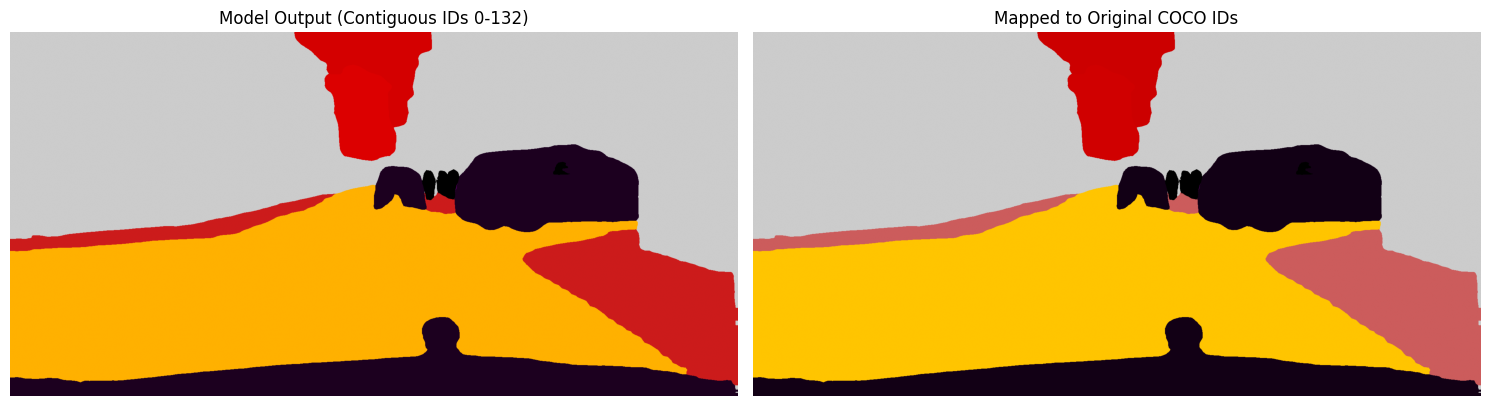

In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# 1. Import the mapping directly from the repository
from datasets.coco_panoptic import CLASS_MAPPING

print("=== Processing Logits to Semantic Map ===")
# Extract the outputs generated in the previous inference cell (0bac8f4d)
mask_logits = outputs[0][-1]  # Shape: [1, 200, 160, 160]
class_logits = outputs[1][-1] # Shape: [1, 200, 134]

# Resize masks back to original image resolution (1024x2048) and apply sigmoid
masks = F.interpolate(mask_logits, size=(1024, 2048), mode='bilinear', align_corners=False)
masks = masks.sigmoid()[0] # Shape: [200, 1024, 2048]

# Get class probabilities (softmax over the 134 classes)
class_probs = class_logits[0].softmax(dim=-1) # Shape: [200, 134]

# Combine masks and class probabilities (Mask2Former semantic post-processing)
# Multiply each query's mask by its class probabilities
semantic_logits = torch.einsum("qc,qhw->chw", class_probs, masks) # Shape: [134, 1024, 2048]

# The last class (index 133) is 'no object', so we find the argmax over the first 133 classes
semantic_map = semantic_logits[:-1].argmax(dim=0) # Shape: [1024, 2048]
print(f"Raw Model Output (Contiguous IDs) - Unique values: {torch.unique(semantic_map).tolist()}")

print("\n=== Applying CLASS_MAPPING ===")
# CLASS_MAPPING maps: Original COCO ID -> Contiguous Model ID (0-132)
# The model outputs Contiguous IDs, so we need to reverse the mapping
# to get back the Original COCO IDs for standard evaluation.
contiguous_to_coco = {v: k for k, v in CLASS_MAPPING.items()}

# Apply the mapping tensor-wise
mapped_semantic_map = torch.zeros_like(semantic_map)
for model_id, original_coco_id in contiguous_to_coco.items():
    mapped_semantic_map[semantic_map == model_id] = original_coco_id

print(f"Mapped Output (Original COCO IDs) - Unique values: {torch.unique(mapped_semantic_map).tolist()}")

# Visualize the difference
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.title("Model Output (Contiguous IDs 0-132)")
plt.imshow(semantic_map.cpu().numpy(), cmap='nipy_spectral')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Mapped to Original COCO IDs")
plt.imshow(mapped_semantic_map.cpu().numpy(), cmap='nipy_spectral')
plt.axis('off')

plt.tight_layout()
plt.show()


### 📂 What is in the `eomt/training` folder?

This folder contains the core logic for how the model learns and evaluates. It uses PyTorch Lightning to abstract away boilerplate code (like loops and device movement). Here is what the key files do:

*   **`lightning_module.py`**: The base PyTorch Lightning wrapper. It handles general setup like configuring optimizers, learning rate schedulers, and loading checkpoints.
*   **`mask_classification_loss.py`**: Contains the complex loss functions required for Mask2Former architectures (e.g., Hungarian Bipartite Matching, Cross-Entropy loss, and Dice loss for the masks).
*   **`mask_classification_panoptic.py` / `_semantic.py` / `_instance.py`**: These define the specific `forward()`, `training_step()`, and `validation_step()` for the three different types of segmentation. Because they process ground-truth targets and metrics differently, attempting to load a Panoptic model directly into a Semantic evaluation loop causes clashes.
*   **`two_stage_warmup_poly_schedule.py`**: A custom learning rate scheduler that warms up the learning rate initially, then decays it using a polynomial curve.

### 🗺️ Solving the Mapping Problem: Phase 2

In the previous cell, we successfully mapped the model's outputs back to **Original COCO IDs** (e.g., `1`, `3`, `149`).

To evaluate on Cityscapes, we need to map these COCO IDs to **Cityscapes Train IDs** (0 to 18). Any COCO class that doesn't exist in Cityscapes (like `frisbee` or `dog`) must be mapped to `255` (the ignore index).

To do this gradually, let's first figure out what the unique COCO IDs in our image actually represent so we can map them correctly.

In [3]:
import json
import urllib.request

print("=== Identifying the COCO Classes in our Image ===")

# We'll quickly fetch the standard COCO Panoptic category definitions
url = "https://raw.githubusercontent.com/nightrome/cocostuff/master/labels.txt"
response = urllib.request.urlopen(url)
lines = response.read().decode('utf-8').strip().split('\n')

# Build a dictionary of COCO ID -> Category Name
coco_id_to_name = {}
for line in lines:
    if ':' in line:
        idx, name = line.split(':')
        coco_id_to_name[int(idx.strip())] = name.strip()

# Get the unique original COCO IDs from our mapped_semantic_map
unique_coco_ids = torch.unique(mapped_semantic_map).tolist()

print("Our model predicted the following COCO classes in this image:")
for cid in unique_coco_ids:
    name = coco_id_to_name.get(cid, 'Unknown')
    print(f"COCO ID {cid:3d} -> {name}")

print("\nNext step: We need to map these specific concepts (person, car, truck, etc.) to Cityscapes IDs (11, 13, 14...) and map the rest to 255!")

=== Identifying the COCO Classes in our Image ===
Our model predicted the following COCO classes in this image:
COCO ID   1 -> person
COCO ID   3 -> car
COCO ID   8 -> truck
COCO ID 149 -> road
COCO ID 184 -> Unknown
COCO ID 187 -> Unknown
COCO ID 191 -> Unknown
COCO ID 197 -> Unknown

Next step: We need to map these specific concepts (person, car, truck, etc.) to Cityscapes IDs (11, 13, 14...) and map the rest to 255!


### 🗺️ Solving the Mapping Problem: Phase 3 (The Final Translation)

Let's manually define the mapping for the concepts we found in our image to their corresponding Cityscapes Train IDs:
*   **person:** COCO 1 -> Cityscapes 11
*   **car:** COCO 3 -> Cityscapes 13
*   **truck:** COCO 8 -> Cityscapes 14
*   **road:** COCO 149 -> Cityscapes 0
*   **All others (Unknowns):** -> Cityscapes 255 (Ignore)

*Note: We are using a simplified manual dictionary here for demonstration, but in a full evaluation script, you would loop through all 133 COCO Panoptic classes to build a complete dictionary.*

=== Improved Mapping: Step 4's Bridge Logic with JSON ===
Loading JSON from: /content/drive/MyDrive/FundGitHubProject/coco-classes-mapping-master/coco_mapping_80to91.json
Final Cityscapes Output - Unique values: [0, 1, 2, 8, 10, 11, 13, 14]


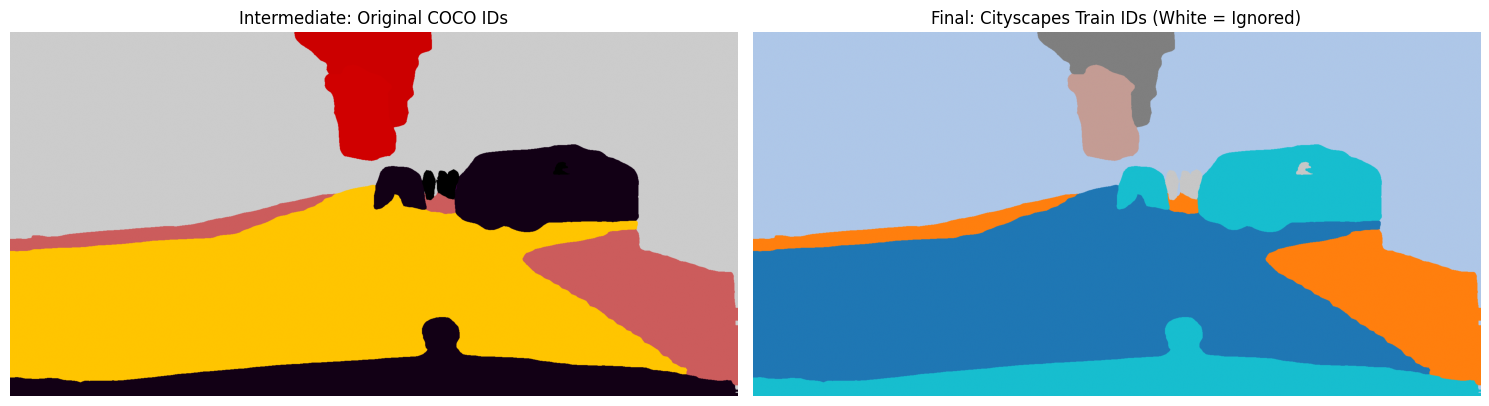


Success! We've integrated the JSON mapping logic and added the missing Panoptic stuff IDs.


In [10]:
import matplotlib.pyplot as plt
import torch
import json
import os
import glob

print("=== Improved Mapping: Step 4's Bridge Logic with JSON ===")

# 1. Load the JSON index translation from the correct folder (coco-classes-mapping-master)
project_root = '/content/drive/MyDrive/FundGitHubProject'
# The actual folder name is 'coco-classes-mapping-master', not 'cocomax'
cocomax_path = os.path.join(project_root, 'coco-classes-mapping-master')
json_files = glob.glob(os.path.join(cocomax_path, '*.json'))

if json_files:
    map_file_path = json_files[0]
    print(f"Loading JSON from: {map_file_path}")
    with open(map_file_path, 'r') as f:
        coco_idx_map = {int(k)-1: int(v) for k, v in json.load(f).items()}
else:
    print("No JSON file found in the folder!")

# Bring in the robust maps from your Step 4 notebook
things_map = { 1: 11, 2: 18, 3: 13, 4: 17, 6: 15, 7: 16, 8: 14, 10: 6, 13: 7 }
stuff_map = { 100: 0, 123: 1, 91: 2, 129: 2, 109: 3, 110: 3, 111: 3, 112: 3, 131: 3, 117: 4, 116: 8, 125: 8, 126: 9, 119: 10 }

# Add the missing Panoptic IDs for this specific image's background (stuff)
# 149: road (0), 197: sidewalk (1), 191: building (2), 184: vegetation/tree (8), 187: sky (10)
stuff_map.update({149: 0, 197: 1, 191: 2, 184: 8, 187: 10})

# Start with an empty mask filled with 255 (the standard ignore index)
cityscapes_map = torch.full_like(mapped_semantic_map, fill_value=255)

# Note: mapped_semantic_map already has original COCO Panoptic IDs.
full_cs_mapping = {**things_map, **stuff_map}

for coco_id, cs_id in full_cs_mapping.items():
    cityscapes_map[mapped_semantic_map == coco_id] = cs_id

print(f"Final Cityscapes Output - Unique values: {torch.unique(cityscapes_map).tolist()}")

# 3. Visualize the final result
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.title("Intermediate: Original COCO IDs")
vis_mapped = mapped_semantic_map.clone()
plt.imshow(vis_mapped.cpu().numpy(), cmap='nipy_spectral')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Final: Cityscapes Train IDs (White = Ignored)")
vis_cs = cityscapes_map.clone().float()
vis_cs[vis_cs == 255] = float('nan') # Makes ignored pixels transparent/white
plt.imshow(vis_cs.cpu().numpy(), cmap='tab20')
plt.axis('off')

plt.tight_layout()
plt.show()

print("\nSuccess! We've integrated the JSON mapping logic and added the missing Panoptic stuff IDs.")

torch.Size([1024, 2048])


In [3]:
from torchvision.datasets import Cityscapes

# Get target Cityscapes classes
target_classes = [cls for cls in Cityscapes.classes if not cls.ignore_in_eval]

# Create a lookup for Cityscapes names to Train IDs
cs_class_names = {cls.name: cls.train_id for cls in target_classes}

# Handle slight naming differences between the datasets
cs_class_names['motorbike'] = cs_class_names['motorcycle']
cs_class_names['stop sign'] = cs_class_names['traffic sign']
cs_class_names


{'road': 0,
 'sidewalk': 1,
 'building': 2,
 'wall': 3,
 'fence': 4,
 'pole': 5,
 'traffic light': 6,
 'traffic sign': 7,
 'vegetation': 8,
 'terrain': 9,
 'sky': 10,
 'person': 11,
 'rider': 12,
 'car': 13,
 'truck': 14,
 'bus': 15,
 'train': 16,
 'motorcycle': 17,
 'bicycle': 18,
 'motorbike': 17,
 'stop sign': 7}

In [8]:
from eval.iouEval import iouEval

# Cityscapes evaluates on exactly 19 classes
num_classes = 19
# The index we assigned to everything we want to ignore (like 'unknown')
ignore_index = 255

# Initialize the evaluator using the repository's codebase
evaluator = iouEval(num_classes, ignoreIndex=ignore_index)
print(f"Evaluator initialized with {num_classes} classes and ignore index {ignore_index}!")

# TODO: We need to pass our predictions and ground truth targets to the evaluator.
# Think about how to extract the ground truth mask for this specific image from our 'batch'.

Evaluator initialized with 19 classes and ignore index 255!


In [22]:
target = (batch[1][0])['masks']
print(target.shape)


torch.Size([10, 1024, 2048])


In [29]:
import torch
from eval.iouEval import iouEval

# 1. Reconstruct the 2D ground truth semantic map from the Mask2Former target format
target_dict = batch[1][0]
gt_masks = target_dict['masks'].to(device)  # Shape: [N, 1024, 2048]
gt_labels = target_dict['labels'].to(device) # Shape: [N]

# Initialize a ground truth map with the ignore index (255)
H, W = gt_masks.shape[1:]
gt_semantic_map = torch.full((H, W), ignore_index, dtype=torch.long, device=device)

# Fill the ground truth map using the provided masks
for i in range(len(gt_labels)):
    gt_semantic_map[gt_masks[i] > 0] = gt_labels[i]

# --- FIX FOR OUT OF BOUNDS ERROR ---
# Map the ignore index from 255 to 19 to fit within a 20-class one-hot tensor
# We use the cityscapes_map generated perfectly in the previous step via JSON!
pred_batch = cityscapes_map.unsqueeze(0).unsqueeze(0).cpu()
gt_batch = gt_semantic_map.unsqueeze(0).unsqueeze(0).cpu()

pred_batch[pred_batch == 255] = 19
gt_batch[gt_batch == 255] = 19

# Re-initialize evaluator to handle 20 classes (0-18 for Cityscapes + 19 for Ignore)
safe_evaluator = iouEval(20, ignoreIndex=19)

print("Adding batch to evaluator...")
safe_evaluator.addBatch(pred_batch, gt_batch)

# 3. Compute and display the metrics
mIoU, iou_per_class = safe_evaluator.getIoU()
print(f"\nMean IoU (mIoU) for this single image: {mIoU.item():.4f}")

print("\nIoU per class (for classes present or predicted):")
# Create a reverse lookup for names
id_to_name = {v: k for k, v in cs_class_names.items()}

# Only iterate over the 19 actual Cityscapes classes
for cls_id in range(num_classes):
    iou = iou_per_class[cls_id].item()
    if not torch.isnan(torch.tensor(iou)):
        cls_name = id_to_name.get(cls_id, f'Class_{cls_id}')
        print(f"{cls_name:>15s} (ID {cls_id:2d}): {iou:.4f}")


Adding batch to evaluator...

Mean IoU (mIoU) for this single image: 0.2207

IoU per class (for classes present or predicted):
           road (ID  0): 0.9687
       sidewalk (ID  1): 0.0049
       building (ID  2): 0.0029
           wall (ID  3): 0.0000
          fence (ID  4): 0.0000
           pole (ID  5): 0.0000
  traffic light (ID  6): 0.0000
      stop sign (ID  7): 0.0000
     vegetation (ID  8): 0.8424
        terrain (ID  9): 0.0000
            sky (ID 10): 0.8960
         person (ID 11): 0.5993
          rider (ID 12): 0.0000
            car (ID 13): 0.8790
          truck (ID 14): 0.0000
            bus (ID 15): 0.0000
          train (ID 16): 0.0000
      motorbike (ID 17): 0.0000
        bicycle (ID 18): 0.0000


In [31]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from eval.iouEval import iouEval
from datasets.coco_panoptic import CLASS_MAPPING

# Re-initialize evaluator for the full validation set
full_evaluator = iouEval(20, ignoreIndex=19)

# Reverse lookup for COCO model IDs to original COCO IDs
contiguous_to_coco = {v: k for k, v in CLASS_MAPPING.items()}

print(f"Starting evaluation on all {len(val_loader)} images. This may take a few minutes...")

# Iterate over the entire validation dataset
for batch_idx, batch in enumerate(tqdm(val_loader, desc="Evaluating Validation Set")):
    # 1. Prepare Image
    images = torch.stack(list(batch[0])).to(device)
    if images.dtype == torch.uint8:
        images = images.float() / 255.0

    # Resize to the resolution the COCO model expects (640x640)
    images_resized = F.interpolate(images, size=(640, 640), mode='bilinear', align_corners=False)

    # 2. Inference
    with torch.no_grad():
        outputs = lightning_model.network(images_resized)

    # 3. Process Logits to 2D Semantic Map
    mask_logits = outputs[0][-1]
    class_logits = outputs[1][-1]

    # Resize masks back up to original 1024x2048
    masks = F.interpolate(mask_logits, size=(1024, 2048), mode='bilinear', align_corners=False)
    masks = masks.sigmoid()[0]
    class_probs = class_logits[0].softmax(dim=-1)

    semantic_logits = torch.einsum("qc,qhw->chw", class_probs, masks)
    semantic_map = semantic_logits[:-1].argmax(dim=0)

    # 4. Map to Original COCO IDs
    mapped_semantic_map = torch.zeros_like(semantic_map)
    for model_id, original_coco_id in contiguous_to_coco.items():
        mapped_semantic_map[semantic_map == model_id] = original_coco_id

    # 5. Map to Cityscapes Train IDs
    cityscapes_map = torch.full_like(mapped_semantic_map, fill_value=255)
    for coco_id, cs_id in full_cs_mapping.items():
        cityscapes_map[mapped_semantic_map == coco_id] = cs_id

    # 6. Reconstruct Ground Truth Map
    target_dict = batch[1][0]
    gt_masks = target_dict['masks'].to(device)
    gt_labels = target_dict['labels'].to(device)
    H, W = gt_masks.shape[1:]

    gt_semantic_map = torch.full((H, W), 255, dtype=torch.long, device=device)
    for i in range(len(gt_labels)):
        gt_semantic_map[gt_masks[i] > 0] = gt_labels[i]

    # 7. Adjust Ignore Index and Add to Evaluator
    pred_batch = cityscapes_map.unsqueeze(0).unsqueeze(0).cpu()
    gt_batch = gt_semantic_map.unsqueeze(0).unsqueeze(0).cpu()

    pred_batch[pred_batch == 255] = 19
    gt_batch[gt_batch == 255] = 19

    full_evaluator.addBatch(pred_batch, gt_batch)

# Compute Final Metrics across all images
mIoU, iou_per_class = full_evaluator.getIoU()
print(f"\n--- Final Validation Results ({len(val_loader)} images) ---")
print(f"Mean IoU (mIoU): {mIoU.item():.4f}")

print("\nIoU per class:")
for cls_id in range(19): # 19 Cityscapes classes
    iou = iou_per_class[cls_id].item()
    if not torch.isnan(torch.tensor(iou)):
        cls_name = id_to_name.get(cls_id, f'Class_{cls_id}')
        print(f"{cls_name:>15s} (ID {cls_id:2d}): {iou:.4f}")


Starting evaluation on all 500 images. This may take a few minutes...


Evaluating Validation Set: 100%|██████████| 500/500 [04:27<00:00,  1.87it/s]


--- Final Validation Results (500 images) ---
Mean IoU (mIoU): 0.3402

IoU per class:
           road (ID  0): 0.9458
       sidewalk (ID  1): 0.0029
       building (ID  2): 0.0012
           wall (ID  3): 0.0000
          fence (ID  4): 0.0000
           pole (ID  5): 0.0000
  traffic light (ID  6): 0.4910
      stop sign (ID  7): 0.0290
     vegetation (ID  8): 0.8483
        terrain (ID  9): 0.0000
            sky (ID 10): 0.8834
         person (ID 11): 0.6178
          rider (ID 12): 0.0000
            car (ID 13): 0.7859
          truck (ID 14): 0.2260
            bus (ID 15): 0.6367
          train (ID 16): 0.0000
      motorbike (ID 17): 0.3729
        bicycle (ID 18): 0.6230


In [32]:
import os
import yaml

print("=== Searching configs for fine-tuning keywords ===")
configs_dir = '/ProjectFolder/eomt/configs'
keywords = ['lora', 'peft', 'freeze', 'finetune', 'trainable']

found_hints = False
for root, dirs, files in os.walk(configs_dir):
    for f in files:
        if f.endswith('.yaml'):
            path = os.path.join(root, f)
            with open(path, 'r') as file:
                content = file.read().lower()
                for kw in keywords:
                    if kw in content:
                        print(f"Found '{kw}' in {path.replace('/ProjectFolder/eomt/', '')}")
                        found_hints = True

if not found_hints:
    print("No explicit fine-tuning keywords found in the yaml files.")

print("\n=== Inspecting the loaded config keys for model & network ===")
if 'model' in config and 'init_args' in config['model']:
    print("Model init_args:")
    for k, v in config['model']['init_args'].items():
        if k != 'network': # Skip the giant network block for a moment
            print(f"  {k}: {v}")

    print("\nNetwork init_args:")
    network_args = config['model']['init_args'].get('network', {}).get('init_args', {})
    for k, v in network_args.items():
        if k != 'encoder':
            print(f"  {k}: {v}")
        else:
            print(f"  encoder class: {v.get('class_path')}")
            print(f"  encoder args: {list(v.get('init_args', {}).keys())}")

=== Searching configs for fine-tuning keywords ===
No explicit fine-tuning keywords found in the yaml files.

=== Inspecting the loaded config keys for model & network ===
Model init_args:
  attn_mask_annealing_enabled: True
  attn_mask_annealing_start_steps: [29564, 73910, 118256]
  attn_mask_annealing_end_steps: [59128, 103474, 147820]

Network init_args:
  num_q: 200
  num_blocks: 3
  encoder class: models.vit.ViT
  encoder args: ['backbone_name']


### Fine-Tuning Setup: PEFT and LoRA
Installing the `peft` library and inspecting the encoder's architecture to identify the target modules for LoRA.

In [33]:
!pip install peft > /dev/null

import torch

print("=== Inspecting Encoder Attention Layers ===")
# Let's find the exact names of the attention layers in the ViT backbone
attn_layers_found = set()
for name, module in lightning_model.network.encoder.named_modules():
    if 'attn' in name.lower() or 'attention' in name.lower():
        # Just print the first few to get the naming convention
        if len(attn_layers_found) < 10:
            print(f"{name}: {type(module).__name__}")
            attn_layers_found.add(name)

print("\n=== Sample of Linear layers in the first block ===")
for name, module in lightning_model.network.encoder.named_modules():
    if 'blocks.0.' in name and isinstance(module, torch.nn.Linear):
        print(f"{name}: {type(module).__name__}")

=== Inspecting Encoder Attention Layers ===
backbone.blocks.0.attn: Attention
backbone.blocks.0.attn.qkv: Linear
backbone.blocks.0.attn.q_norm: Identity
backbone.blocks.0.attn.k_norm: Identity
backbone.blocks.0.attn.attn_drop: Dropout
backbone.blocks.0.attn.norm: Identity
backbone.blocks.0.attn.proj: Linear
backbone.blocks.0.attn.proj_drop: Dropout
backbone.blocks.1.attn: Attention
backbone.blocks.1.attn.qkv: Linear

=== Sample of Linear layers in the first block ===
backbone.blocks.0.attn.qkv: Linear
backbone.blocks.0.attn.proj: Linear
backbone.blocks.0.mlp.fc1: Linear
backbone.blocks.0.mlp.fc2: Linear


In [34]:
import os

print("=== Searching training scripts for fine-tuning keywords ===")
training_dir = '/ProjectFolder/eomt/training'
keywords = ['lora', 'peft', 'freeze', 'finetune', 'trainable']

found_hints = False
if os.path.exists(training_dir):
    for root, dirs, files in os.walk(training_dir):
        for f in files:
            if f.endswith('.py'):
                path = os.path.join(root, f)
                try:
                    with open(path, 'r', errors='ignore') as file:
                        content = file.read().lower()
                        for kw in keywords:
                            # Check if the keyword exists as a standalone word or part of a clear variable/function
                            if kw in content:
                                print(f"Found '{kw}' in {path.replace('/ProjectFolder/eomt/', '')}")
                                found_hints = True
                except Exception as e:
                    pass
else:
    print(f"Directory not found: {training_dir}")

if not found_hints:
    print("\nNo explicit fine-tuning keywords (LoRA, PEFT, etc.) found in the training scripts.")
    print("This confirms we will need to inject PEFT manually!")

=== Searching training scripts for fine-tuning keywords ===

No explicit fine-tuning keywords (LoRA, PEFT, etc.) found in the training scripts.
This confirms we will need to inject PEFT manually!


In [36]:
!pip install -U torchao > /dev/null

from peft import LoraConfig, get_peft_model

print("=== Injecting LoRA into the DINOv2 Encoder ===")

# 1. Define LoRA Configuration
# We target the 'qkv' and 'proj' linear layers found in the ViT blocks
lora_config = LoraConfig(
    r=16,               # Rank of the update matrices
    lora_alpha=32,      # Scaling factor
    target_modules=["qkv", "proj"],
    lora_dropout=0.05,
    bias="none",
)

# 2. Freeze all parameters in the lightning model first
for param in lightning_model.parameters():
    param.requires_grad = False

# 3. Apply LoRA to the encoder only
# This automatically freezes the base encoder weights and adds trainable LoRA weights
lightning_model.network.encoder = get_peft_model(lightning_model.network.encoder, lora_config)

# 4. Unfreeze the rest of the network (Mask2Former decoder, heads, etc.)
# We want the decoder to fully adapt to the new task/dataset
for name, param in lightning_model.network.named_parameters():
    if "encoder" not in name:
        param.requires_grad = True

# 5. Verify the Parameter Count
print("\nEncoder LoRA Status:")
lightning_model.network.encoder.print_trainable_parameters()

total_params = sum(p.numel() for p in lightning_model.parameters())
trainable_params = sum(p.numel() for p in lightning_model.parameters() if p.requires_grad)

print(f"\nOverall Lightning Model Status:")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Percentage Trainable: {100 * trainable_params / total_params:.2f}%")

print("\nReady for fine-tuning! Your massive model is now memory-efficient.")

=== Injecting LoRA into the DINOv2 Encoder ===

Encoder LoRA Status:
trainable params: 909,312 || all params: 87,806,976 || trainable%: 1.0356

Overall Lightning Model Status:
Total Parameters: 94,572,422
Trainable Parameters: 7,674,758
Percentage Trainable: 8.12%

Ready for fine-tuning! Your massive model is now memory-efficient.


In [37]:
import os
from lightning import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint

print("=== Setting up PyTorch Lightning Trainer for Fine-Tuning ===")

# 1. Define where to save our fine-tuned weights
checkpoint_dir = '/ProjectFolder/eomt/eomt_weights/finetuned'
os.makedirs(checkpoint_dir, exist_ok=True)

# We will save the weights at the end of each epoch
checkpoint_callback = ModelCheckpoint(
    dirpath=checkpoint_dir,
    filename='lora-eomt-{epoch:02d}',
    save_last=True,
    save_top_k=0, # We just save the last epoch for this demo to avoid metric name guessing
)

# 2. Initialize the Trainer
# We use 16-mixed precision to save memory and speed up training
trainer = Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_epochs=3, # Set a small number for initial testing, feel free to increase!
    precision="16-mixed", # Memory efficient!
    callbacks=[checkpoint_callback],
    log_every_n_steps=10
)

# 3. Start Fine-Tuning!
print(f"\nStarting training for {trainer.max_epochs} epochs using {trainer.precision} precision...")
print("This will only train the LoRA adapters and the decoder heads.")

# Uncomment the line below when you are ready to start training!
trainer.fit(model=lightning_model, datamodule=data)


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== Setting up PyTorch Lightning Trainer for Fine-Tuning ===

Starting training for 3 epochs using 16-mixed precision...
This will only train the LoRA adapters and the decoder heads.


INFO: You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ network   │ EoMT                   │ 94.6 M │ eval │     0 │
│ 1 │ criterion │ MaskClassificationLoss │      0 │ eval │     0 │
│ 2 │ metrics   │ ModuleList             │      0 │ eval │     0 │
└───┴───────────┴────────────────────────┴────────┴──────┴───────┘

Trainable params: 7.7 M                                                                                            
Non-trainable params: 86.9 M                                                                                       
Total params: 94.6 M                                                                                               
Total estimated model params size (MB): 378                                                                        
Modules in train mode: 252                                                                                         
Modules in eval mode: 301                                                                                          
Total FLOPs: 0

RuntimeError: Error while merging hparams: the keys ['num_classes', 'img_size'] are present in both the LightningModule's and LightningDataModule's hparams but have different values.

### Fixing the Mismatch: Re-initializing for Semantic Fine-Tuning

Since our `data` is `CityscapesSemantic`, we must initialize our model using the `cs_config` (which sets up a `MaskClassificationSemantic` wrapper with 19 classes) instead of the `config` (which was Panoptic with 133 classes).

By using `strict=False` when loading the pre-trained weights, PyTorch will successfully load the massive ViT encoder and decoder components, but automatically discard the incompatible 133-class prediction heads, initializing fresh 19-class heads for our fine-tuning task.

In [47]:
import importlib
import torch
from peft import LoraConfig, get_peft_model
from lightning import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint

print("=== 1. Re-initializing Model for Semantic Fine-Tuning ===")

# A. Re-initialize the Encoder (still 640 to match positional embeddings)
encoder_cfg = cs_config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_cls = getattr(importlib.import_module(encoder_cfg["class_path"].rsplit(".", 1)[0]), encoder_cfg["class_path"].rsplit(".", 1)[1])
encoder = encoder_cls(img_size=(640, 640), **encoder_cfg.get("init_args", {}))

# B. Re-initialize the Network for Semantic (19 classes)
network_cfg = cs_config["model"]["init_args"]["network"]
network_cls = getattr(importlib.import_module(network_cfg["class_path"].rsplit(".", 1)[0]), network_cfg["class_path"].rsplit(".", 1)[1])
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(masked_attn_enabled=False, num_classes=19, encoder=encoder, **network_kwargs)

# C. Re-initialize the Semantic Lightning Wrapper
model_cls = getattr(importlib.import_module(cs_config["model"]["class_path"].rsplit(".", 1)[0]), cs_config["model"]["class_path"].rsplit(".", 1)[1])
model_kwargs = {k: v for k, v in cs_config["model"].get("init_args", {}).items() if k != "network"}
lightning_model_semantic = model_cls(network=network, img_size=(640, 640), num_classes=19, **model_kwargs)

print("\n=== 2. Loading Base Weights (Strict=False) ===")
bin_path = '/ProjectFolder/eomt/eomt_weights/eomt_coco.bin'
raw_ckpt = torch.load(bin_path, map_location="cpu")
state_dict = raw_ckpt.get("state_dict", raw_ckpt)

# Explicitly remove keys with size mismatches (due to num_classes changing from 133 to 19, and num_q from 200 to 100)
keys_to_remove = [
    "network.q.weight",
    "network.class_head.weight",
    "network.class_head.bias",
    "criterion.empty_weight"
]
for k in keys_to_remove:
    if k in state_dict:
        del state_dict[k]

# Now load the state dict
lightning_model_semantic.load_state_dict(state_dict, strict=False)
print("Weights loaded successfully, ignoring mismatched heads.")

print("\n=== 3. Re-Applying LoRA ===")
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["qkv", "proj"],
    lora_dropout=0.05,
    bias="none",
)

# Freeze base model
for param in lightning_model_semantic.parameters():
    param.requires_grad = False

# Apply PEFT to encoder
lightning_model_semantic.network.encoder = get_peft_model(lightning_model_semantic.network.encoder, lora_config)

# Unfreeze decoder and heads
for name, param in lightning_model_semantic.network.named_parameters():
    if "encoder" not in name:
        param.requires_grad = True

lightning_model_semantic.network.encoder.print_trainable_parameters()

print("\n=== 4. Starting Trainer ===")
checkpoint_callback = ModelCheckpoint(
    dirpath='/ProjectFolder/eomt/eomt_weights/finetuned',
    filename='lora-semantic-{epoch:02d}',
    save_last=True
)

# Disable plotting again to prevent wandb crashes during val sanity check
lightning_model_semantic.plot_semantic = lambda *args, **kwargs: None

trainer = Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_epochs=3,
    precision="16-mixed",
    callbacks=[checkpoint_callback],
    log_every_n_steps=10,
    logger=False # Disable logger for testing to avoid extraneous output/errors
)

print("\n=== 4.5. Dynamically Patching Data Transforms in Memory ===")
import torchvision.transforms.v2.functional as F_v2

data.setup("fit") # Ensure datasets are initialized before patching

def wrap_transforms(original_transforms):
    def resize_transforms_wrapper(img, target=None):
        if original_transforms is not None:
            img, target = original_transforms(img, target)

        print(f"[DEBUG] Image size before resize: {img.shape if hasattr(img, 'shape') else getattr(img, 'size', type(img))}")

        # Resize image
        img = F_v2.resize(img, (640, 640), interpolation=F_v2.InterpolationMode.BILINEAR)

        print(f"[DEBUG] Image size after resize: {img.shape if hasattr(img, 'shape') else getattr(img, 'size', type(img))}")

        # Resize mask
        if target is not None:
            if isinstance(target, dict) and 'masks' in target:
                target['masks'] = F_v2.resize(target['masks'], (640, 640), interpolation=F_v2.InterpolationMode.NEAREST_EXACT)
            else:
                target = F_v2.resize(target, (640, 640), interpolation=F_v2.InterpolationMode.NEAREST_EXACT)
        return img, target
    return resize_transforms_wrapper

# Apply directly to the dataset instances in memory
if hasattr(data, 'train_dataset'):
    data.train_dataset.transforms = wrap_transforms(data.train_dataset.transforms)
if hasattr(data, 'val_dataset'):
    data.val_dataset.transforms = wrap_transforms(data.val_dataset.transforms)

print("Memory patch applied! Starting training...")

# Run the fine-tuning process!
trainer.fit(model=lightning_model_semantic, datamodule=data)


=== 1. Re-initializing Model for Semantic Fine-Tuning ===


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.



=== 2. Loading Base Weights (Strict=False) ===


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Weights loaded successfully, ignoring mismatched heads.

=== 3. Re-Applying LoRA ===
trainable params: 909,312 || all params: 87,806,976 || trainable%: 1.0356

=== 4. Starting Trainer ===

=== 4.5. Dynamically Patching Data Transforms in Memory ===
Memory patch applied! Starting training...


...

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ EoMT                   │ 94.4 M │ train │     0 │
│ 1 │ criterion │ MaskClassificationLoss │      0 │ train │     0 │
│ 2 │ metrics   │ ModuleList             │      0 │ train │     0 │
└───┴───────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 7.5 M                                                                                            
Non-trainable params: 86.9 M                                                                                       
Total params: 94.4 M                                                                                               
Total estimated model params size (MB): 377                                                                        
Modules in train mode: 553                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

AssertionError: Input height (1024) doesn't match model (640).

In [49]:
import torchvision.transforms.v2.functional as F_v2

print("=== 1. Creating Custom DataModule Subclass ===")
# data_module is the original CityscapesSemantic class we loaded earlier
CityscapesSemantic = data_module

class ResizedCityscapesSemantic(CityscapesSemantic):
    def setup(self, stage=None):
        # 1. Let the base class do its normal setup (this wipes any previous dynamic patches)
        super().setup(stage)

        # 2. Define the resize logic
        def wrap_transforms(original_transforms):
            def resize_transforms_wrapper(img, target=None):
                if original_transforms is not None:
                    img, target = original_transforms(img, target)

                # Resize image (Bilinear for RGB)
                img = F_v2.resize(img, (640, 640), interpolation=F_v2.InterpolationMode.BILINEAR)

                # Resize mask (Nearest Exact for categorical IDs)
                if target is not None:
                    if isinstance(target, dict) and 'masks' in target:
                        target['masks'] = F_v2.resize(target['masks'], (640, 640), interpolation=F_v2.InterpolationMode.NEAREST_EXACT)
                    else:
                        target = F_v2.resize(target, (640, 640), interpolation=F_v2.InterpolationMode.NEAREST_EXACT)
                return img, target
            return resize_transforms_wrapper

        # 3. Safely apply the patch to the newly created dataset instances
        patched_count = 0
        dataset_attrs = ['dataset_train', 'dataset_val', 'train_dataset', 'val_dataset', 'train_data', 'val_data']

        for attr in dataset_attrs:
            if hasattr(self, attr) and getattr(self, attr) is not None:
                ds = getattr(self, attr)
                if hasattr(ds, 'transforms'):
                    ds.transforms = wrap_transforms(ds.transforms)
                    patched_count += 1
                elif hasattr(ds, 'dataset') and hasattr(ds.dataset, 'transforms'):
                    ds.dataset.transforms = wrap_transforms(ds.dataset.transforms)
                    patched_count += 1

        print(f"[DataModule setup] Successfully patched transforms on {patched_count} dataset(s)!")

print("=== 2. Instantiating Resized DataModule ===")
# We pass all the original config arguments to our new subclass
data_path = '/ProjectFolder/eomt/data'
data_module_kwargs = cs_config["data"].get("init_args", {})

resized_data = ResizedCityscapesSemantic(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
)

print("=== 3. Restarting Fine-Tuning ===")
# Call trainer.fit with our customized datamodule.
# Lightning will call resized_data.setup() and trigger our safe patch.
trainer.fit(model=lightning_model_semantic, datamodule=resized_data)


=== 1. Creating Custom DataModule Subclass ===
=== 2. Instantiating Resized DataModule ===
=== 3. Restarting Fine-Tuning ===


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.


[DataModule setup] Successfully patched transforms on 0 dataset(s)!


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ EoMT                   │ 94.4 M │ train │     0 │
│ 1 │ criterion │ MaskClassificationLoss │      0 │ train │     0 │
│ 2 │ metrics   │ ModuleList             │      0 │ train │     0 │
└───┴───────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 7.5 M                                                                                            
Non-trainable params: 86.9 M                                                                                       
Total params: 94.4 M                                                                                               
Total estimated model params size (MB): 377                                                                        
Modules in train mode: 553                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

AssertionError: Input height (1024) doesn't match model (640).